# Incident Prediction from Time-Series Metrics

Our task requires implementation of a machine learning model that predicts whether an incident will occur in the next **H time steps** based on the previous **W observations** of system metrics.

## Problem Formulation

Let define **m** system metrics at time **t** as $X_t = (X_t^1, X_t^2, ..., X_t^m)$. For a window of time size W the model input will be:..
$$
[X_{t-W+1}, ..., X_t].
$$
The model predicts whether an incident will occur within the next H time steps:
$$
y_t = \left\{ \begin{array}{l}
1 \mbox{ if an inciden occurs in } [t+1, t+H], \\
0 \mbox{ otherwise. }
\end{array}\right.
$$
This converts the time-series prediction problem into a supervised classification problem.

## Synthetic Dataset

We generate a synthetic multivariate time-series dataset representing system monitoring metrics. The dataset contains the following metrics:
- CPU usage,
- memory usage,
- request latency,
- error rate.
 
We simulate 10,000 time steps. Most of the time, the system is in a "Normal" state with random noise. However, we manually create "Incidents" and additionaly, to simulate reall system behaviour, for 40 steps before each incident, we program a "drift" where the values start to climb.

In [9]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')

from functions import *

np.random.seed(123)

df = generate_data()
df.to_csv('../data/raw/data.csv', index = False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


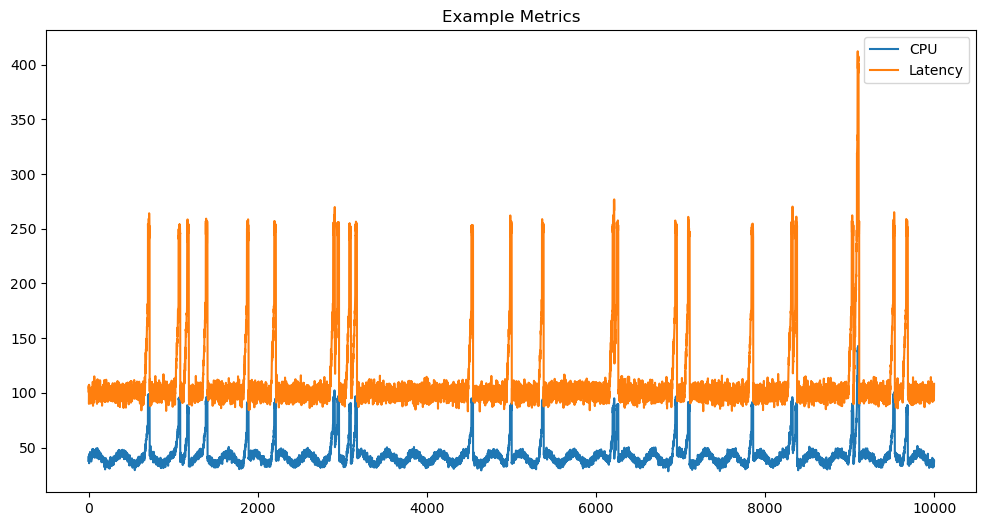

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df.cpu, label="CPU")
plt.plot(df.latency, label="Latency")
plt.legend()
plt.title("Example Metrics")
plt.show()

## Sliding Window Formulation

As we previously defined, we need to transform a single long table of numbers into "samples". Each sample consists of a window of size **W** (the past) and a label $\mathbf{y_t}$ (the future).
Let say $W=30, \ H=20$, our goal is to build the model that will look at the last 30 minutes of data to decide if an incident occures at any point in the next 20 minutes.
We flatten the window $[W_{t-W+1}, ..., X_t]$ into a long row of features so a standard ML model can read it:

In [11]:
W_size = 30
H_size = 20
X_samples, y_labels = sliding_windows(df, W=W_size, H=H_size)

train_split = int(len(X_samples) * 0.75)
X_train = X_samples[:train_split]
X_test = X_samples[train_split:]
y_train = y_labels[:train_split]
y_test = y_labels[train_split:]

## Model training and Evaluation

To solve this task we decided to use a **Random Forest Clasifier** because it's non-parametric and good with outliers. When evaluating the model using just Accuracy may semms insufficient due to rarity of incidents, we can get good accuracy just by labeling "No Incident" every time. Instead we should consider **Precision** and **Recall**.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=123)
clf.fit(X_train, y_train)

y_pred_probs = clf.predict_proba(X_test)[:, 1]
custom_threshold = 0.35
y_final_pred = (y_pred_probs >= custom_threshold).astype(int)

print(classification_report(y_test, y_final_pred))

ModuleNotFoundError: No module named 'sklearn'